<a href="https://colab.research.google.com/github/Pranaybannu/Classification-models-for-machine-failure/blob/main/TSC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name**    -
# **CLASSIFICATION MODELS FOR PREDICTING MACHINE/EQUIPMENT FAILURE IN TATA STEEL**


# **Project Summary -**


**Machines are absolutely central to operations in Tata Steel, as steel manufacturing is a highly automated, continuous, and precision-driven process. Modern machinery enables uninterrupted production with minimal human intervention, ensuring high efficiency and consistent quality. Additionally, machines reduce human exposure to hazardous environments, automate high-risk tasks, and significantly enhance overall workplace safety and productivity.**

**As a leader in the steel manufacturing industry, Tata Steel continuously strives to improve its production processes by leveraging advanced data analytics and machine learning techniques. Machine learning enables a shift from reactive to predictive maintenance by analyzing real-time sensor data such as temperature, torque, pressure, and vibration. These models can identify hidden patterns and anomalies that signal potential failures before they occur. Early detection helps prevent unexpected breakdowns, reduces costly downtime, and improves overall operational efficiency.**

**In large-scale industrial environments like Tata Steel, where continuous production is critical, machine learning supports optimized maintenance planning, extends equipment lifespan, and enables data-driven decision-making. This ultimately leads to increased productivity, reduced operational costs, and improved system reliability.**

**The dataset used in this project contains various operational parameters and machine failure types associated with steel production processes. By analyzing this data, the objective is to develop a predictive model capable of anticipating machine failures in advance, thereby enabling proactive maintenance and enhancing overall operational performance.**

# **Problem Statement**


**The objective of this project was to develop a predictive maintenance system capable of:**

1. Detecting whether a machine failure would occur.
2. Identifying the specific type of failure when a failure occurs.

# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [ ]:
# Import Libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,recall_score,f1_score,classification_report

### Dataset Loading

In [ ]:
# Load Dataset
train = pd.read_csv("/content/drive/MyDrive/M6/train.csv")     ##training dataset


### Dataset First View

In [ ]:
# Dataset First Look
train.head()

,id,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,0,L50096,L,300.6,309.6,1596,36.1,140,0,0,0,0,0,0
1,1,M20343,M,302.6,312.1,1759,29.1,200,0,0,0,0,0,0
2,2,L49454,L,299.3,308.5,1805,26.5,25,0,0,0,0,0,0
3,3,L53355,L,301.0,310.9,1524,44.3,197,0,0,0,0,0,0
4,4,M24050,M,298.0,309.0,1641,35.4,34,0,0,0,0,0,0


In [ ]:
train.tail()

,id,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
136424,136424,M22284,M,300.1,311.4,1530,37.5,210,0,0,0,0,0,0
136425,136425,H38017,H,297.5,308.5,1447,49.1,2,0,0,0,0,0,0
136426,136426,L54690,L,300.5,311.8,1524,38.5,214,0,0,0,0,0,0
136427,136427,L53876,L,301.7,310.9,1447,46.3,42,0,0,0,0,0,0
136428,136428,L47937,L,296.9,308.1,1557,39.3,229,0,0,0,0,0,0


### Dataset Rows & Columns count

In [ ]:
# Dataset Rows & Columns count
train.shape

(136429, 14)

### Dataset Information

In [ ]:
# Dataset Info
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 136429 entries, 0 to 136428
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       136429 non-null  int64  
 1   Product ID               136429 non-null  object 
 2   Type                     136429 non-null  object 
 3   Air temperature [K]      136429 non-null  float64
 4   Process temperature [K]  136429 non-null  float64
 5   Rotational speed [rpm]   136429 non-null  int64  
 6   Torque [Nm]              136429 non-null  float64
 7   Tool wear [min]          136429 non-null  int64  
 8   Machine failure          136429 non-null  int64  
 9   TWF                      136429 non-null  int64  
 10  HDF                      136429 non-null  int64  
 11  PWF                      136429 non-null  int64  
 12  OSF                      136429 non-null  int64  
 13  RNF                      136429 non-null  int64  
dtypes: f

#### Duplicate Values

In [ ]:
# Dataset Duplicate Value Count
train.duplicated().sum()  ##no duplicates found

np.int64(0)

#### Missing Values/Null Values

In [ ]:
# Missing Values/Null Values Count
train.isnull().sum().sum()   ## no null or missing values found

np.int64(0)

### What did you know about your dataset?



1.   **No duplicates** and **null values** found in the dataset.
2.   The dataset contains **136429 rows and 14 columns/features**. Out of the 14 column **two are unique identifiers ('ID','PRODUCT-ID')**, these two columns **do not have any predictive power**. Therefore, these two columns will be removed during preprocessing
3.  Dataset contains ***two object datatype*** columns and ***eleven numeric datatype*** columns



## ***2. Understanding Your Variables***

In [ ]:
# Dataset Columns
train.columns

Index(['id', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='object')

In [ ]:
# Dataset Describe
train.describe(include='number')

,id,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,136429.000000,136429.000000,136429.000000,136429.000000,136429.000000,136429.000000,136429.000000,136429.000000,136429.000000,136429.000000,136429.000000,136429.000000
mean,68214.000000,299.862776,309.941070,1520.331110,40.348643,104.408901,0.015744,0.001554,0.005160,0.002397,0.003958,0.002258
std,39383.804275,1.862247,1.385173,138.736632,8.502229,63.965040,0.124486,0.039389,0.071649,0.048899,0.062789,0.047461
min,0.000000,295.300000,305.800000,1181.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,34107.000000,298.300000,308.700000,1432.000000,34.600000,48.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,68214.000000,300.000000,310.000000,1493.000000,40.400000,106.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,102321.000000,301.200000,310.900000,1580.000000,46.100000,159.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,136428.000000,304.400000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


### Variables Description

###
1.   **Product-ID** :- Unique identifier for each product (eg:'L50096')

# **NUMERICAL DATA**  
2. **Air Temperature**:- Tells about the level of heat/temperature in the
surrounding air (in kelvin scale).
3. **Process Temperature** :- Refers to the temperature of the materials, system or operation during an industrial process (in kelvins).
4. **Rotational Speed(rpm)**:- Speed at which the machine rotates around its axis, typically measured in rpm.  
5. **Torque** :- Force applied to an object, that causes it to rotate around an axis, typically measured in Newton-meters(Nm).
6. **Tool Wear** :- Gradual loss of material or efficiency of a tool due to **continuous use**, friction and heat generated during the process (in min).

#**CATEGORICAL DATA**
7. **Machine Failure (TARGET)**:- Indicates weather the machine has experienced a failure (0--> Not failed, 1--> failed)
8. **TWF (Tool Wear Failure)**:- Occurs when a tool fails after a certain amount of time (0 and 1)
9. **Type** :- Indicates the quality of each product (L--> low, M--> Medium, H--> high)
10. **HDF (Heat Dissipation Failure)**:- Inability of a machine to effectively release heat, leading to overheating and causes system to breakdown (0 and 1).
11. **Power Failure** :- Loss or interruption of electrical supply to the machine (0,1)
12. **Overstrain Failure** :- Occurs when a machine or its components are subjected to stress or load beyond their designed limit, causing damage, deformation or breakdown (0,1).
13. **Random Failure**:- Unexpected machine failure/breakdown that occurs without any identifiable pattern or prior indication(0,1).



### Check Unique Values for each variable.

In [ ]:
# Check Unique Values for each variable.
print(train['Machine failure'].value_counts(),"\n")
print(train['TWF'].value_counts(),"\n")
print(train['HDF'].value_counts(),"\n")
print(train['PWF'].value_counts(),"\n")
print(train['OSF'].value_counts(),"\n")
print(train['RNF'].value_counts(),"\n")

Machine failure
0    134281
1      2148
Name: count, dtype: int64 

TWF
0    136217
1       212
Name: count, dtype: int64 

HDF
0    135725
1       704
Name: count, dtype: int64 

PWF
0    136102
1       327
Name: count, dtype: int64 

OSF
0    135889
1       540
Name: count, dtype: int64 

RNF
0    136121
1       308
Name: count, dtype: int64 



### **High class imabalance in the categorical column values(0,1)**
**Especially in the Target column(Machine failure) 0-->134281, 1-->2148**

## 3. ***Data Wrangling/Feature Engineering***

### Data Wrangling Code

In [ ]:
# Write your code to make your dataset analysis ready.
train.head()

,id,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,0,L50096,L,300.6,309.6,1596,36.1,140,0,0,0,0,0,0
1,1,M20343,M,302.6,312.1,1759,29.1,200,0,0,0,0,0,0
2,2,L49454,L,299.3,308.5,1805,26.5,25,0,0,0,0,0,0
3,3,L53355,L,301.0,310.9,1524,44.3,197,0,0,0,0,0,0
4,4,M24050,M,298.0,309.0,1641,35.4,34,0,0,0,0,0,0


In [ ]:
## removing columns id and product id
train = train.drop(['id','Product ID'], axis=1)

In [ ]:
train.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,L,300.6,309.6,1596,36.1,140,0,0,0,0,0,0
1,M,302.6,312.1,1759,29.1,200,0,0,0,0,0,0
2,L,299.3,308.5,1805,26.5,25,0,0,0,0,0,0
3,L,301.0,310.9,1524,44.3,197,0,0,0,0,0,0
4,M,298.0,309.0,1641,35.4,34,0,0,0,0,0,0


In [ ]:
## calculating temperature difference, and adding it as a column
train['temp_diff(k)'] = train['Process temperature [K]'] - train['Air temperature [K]']

In [ ]:
train.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,temp_diff(k)
0,L,300.6,309.6,1596,36.1,140,0,0,0,0,0,0,9.0
1,M,302.6,312.1,1759,29.1,200,0,0,0,0,0,0,9.5
2,L,299.3,308.5,1805,26.5,25,0,0,0,0,0,0,9.2
3,L,301.0,310.9,1524,44.3,197,0,0,0,0,0,0,9.9
4,M,298.0,309.0,1641,35.4,34,0,0,0,0,0,0,11.0


In [ ]:
##power in KW
train['power[kw]'] = round((train['Torque [Nm]']* train['Rotational speed [rpm]'])/9548.8,2)

In [ ]:
train.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,temp_diff(k),power[kw]
0,L,300.6,309.6,1596,36.1,140,0,0,0,0,0,0,9.0,6.03
1,M,302.6,312.1,1759,29.1,200,0,0,0,0,0,0,9.5,5.36
2,L,299.3,308.5,1805,26.5,25,0,0,0,0,0,0,9.2,5.01
3,L,301.0,310.9,1524,44.3,197,0,0,0,0,0,0,9.9,7.07
4,M,298.0,309.0,1641,35.4,34,0,0,0,0,0,0,11.0,6.08


### What all manipulations have you done and insights you found?



1.   **Dropped columns with no predictive power (ID, PRODUCT ID).**
2.   **Created a feature power[kw] by multiplying torque and rotational speed**
3.   **Created another feature temperature difference, by calculating the difference between process temperature and surrounding air temperature.**



## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

####**Chart1- Histogram**

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly as px

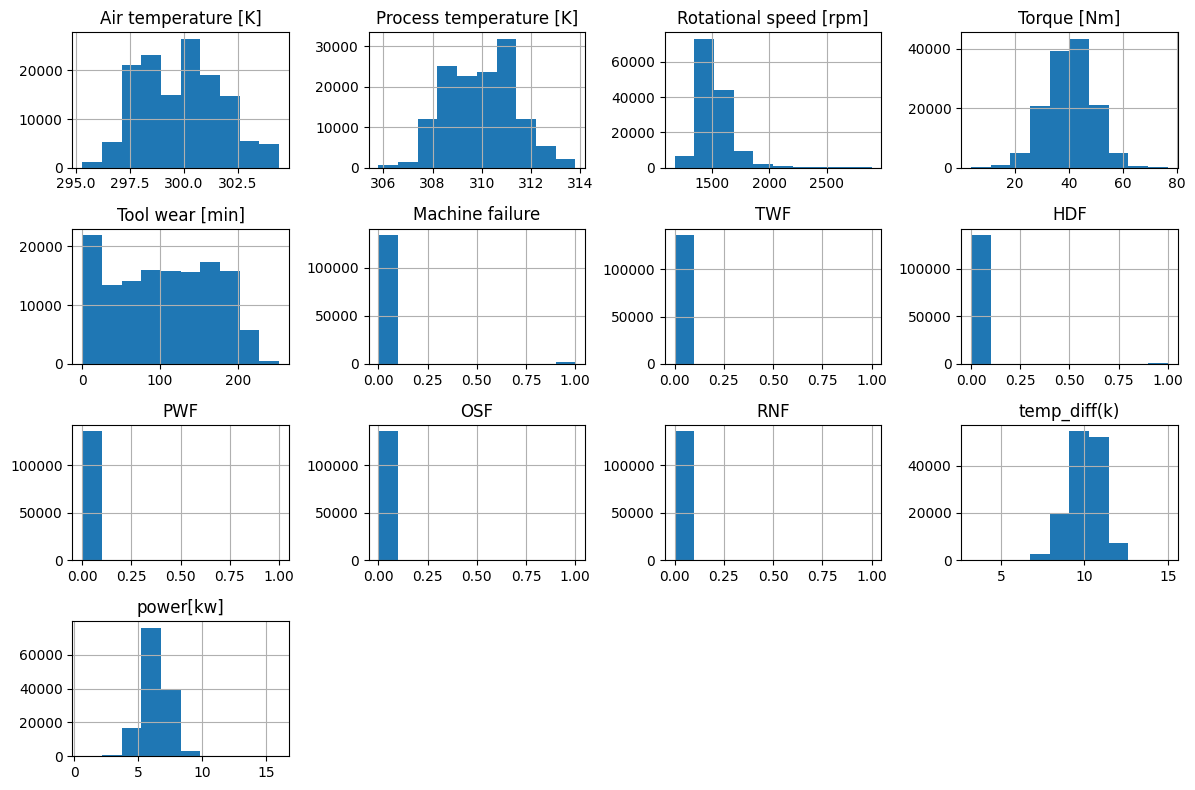

In [ ]:
# Chart - 1 Basic HISTOGRAM chart code
train.hist(figsize=(12,8))
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

**Basic Histogram to observe the distribution of data, especially numerical columns.**

##### 2. What is/are the insight(s) found from the chart?



1.   Most numerical columns are **normally distributed(approximately)**.
2.   There is a high class imablance in categorical columns.



#### **Chart - 2:- COUNT PLOT**

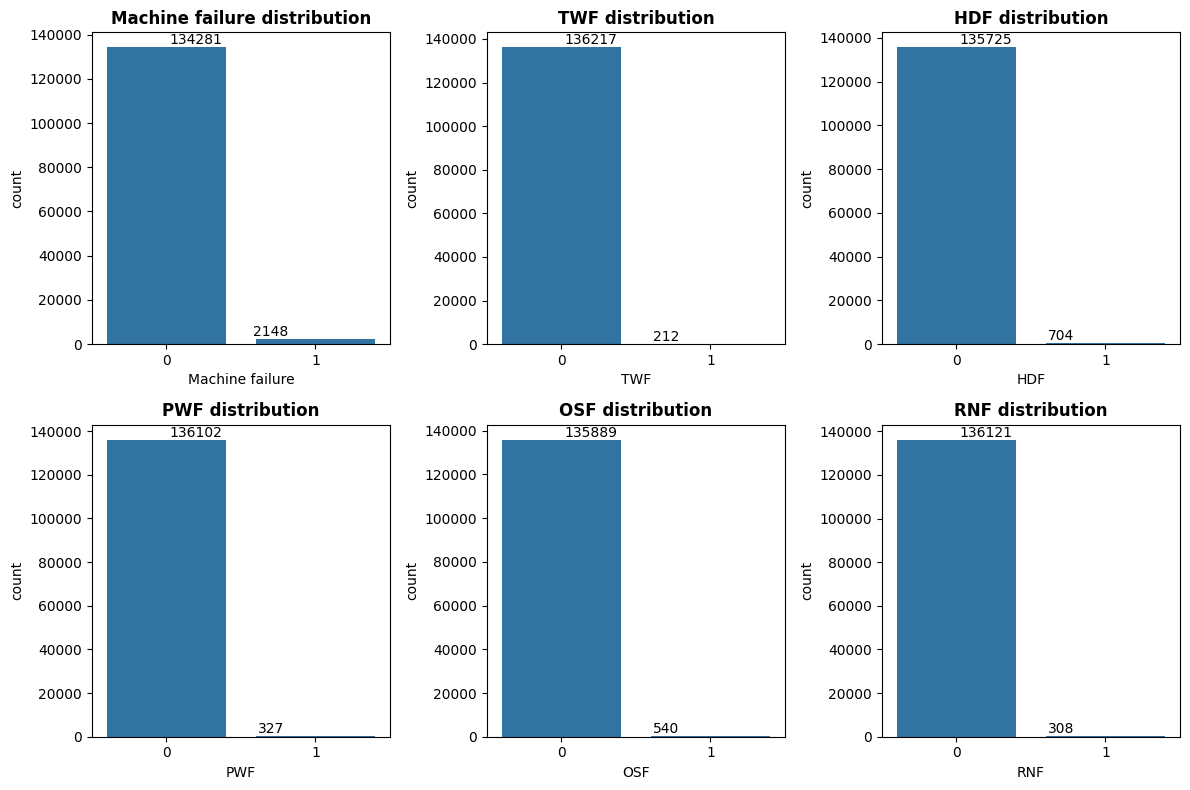

In [ ]:
columns = ['Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']
fig,axes = plt.subplots(2,3,figsize=(12,8))
axes = axes.flatten()
for i,col in enumerate(columns):
  ax=axes[i]
  sns.countplot(x=col,data=train,ax=axes[i])
  ax.set_title(f'{col} distribution',color='black',weight='bold')
  for i in ax.patches:
    height = int(i.get_height())
    ax.text((i.get_x()+i.get_width())/2, height,str(height),ha='center',va='bottom')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

**To visualize the class(0,1) imbalance in the categorical columns.**

##### 2. What is/are the insight(s) found from the chart?

1.   In all the columns, the **class 0(no failure) has more count (>1.35 lakhs) when compared to class 1(failure)**
2.   **class 1 is under-represented**



#### **Scatter plot**

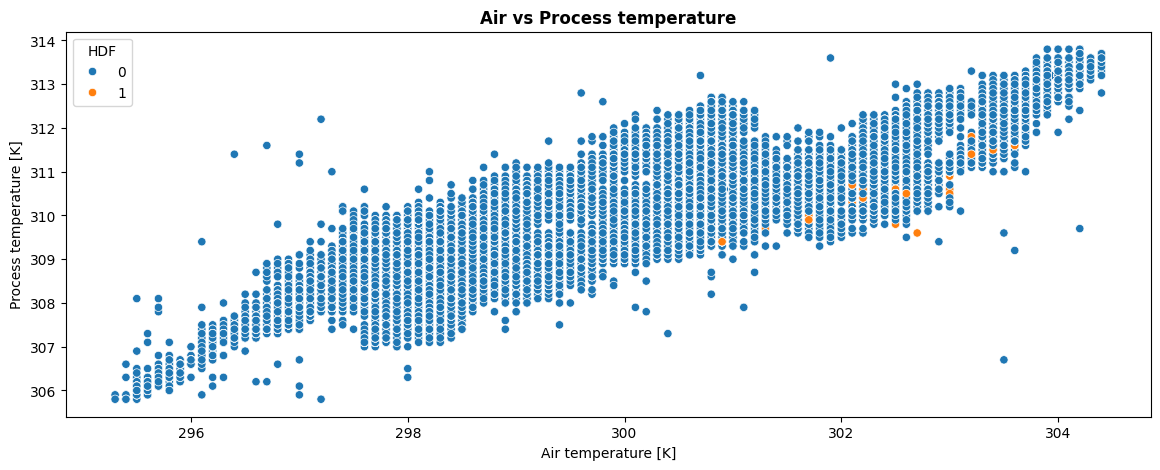

In [ ]:
plt.figure(figsize=(14,5))
sns.scatterplot(x='Air temperature [K]', y='Process temperature [K]',data=train,hue='HDF')
plt.title("Air vs Process temperature", weight='bold')
plt.show()

##### 1. Why did you pick the specific chart?

**To visualize the relation between Air and Process temperatures with HDF as a hue parameter**

##### 2. What is/are the insight(s) found from the chart?



1.   Air temperature and Process temperature **move together tightly** (strongly related)
2.   Using both in a classification model like Logistic Regression can **cause unstable coefficients and reduced interpretability.** Therefore, we might use *temp_diff* as a feature.
3. **HDF=1 are very few/under-represented** and spread across the range. Therefore, temperature alone can not be used for HDF prediction.
4. **Few Outliers**, could be sensor noise or rare abnormalities.



#### **Box Plot 1**

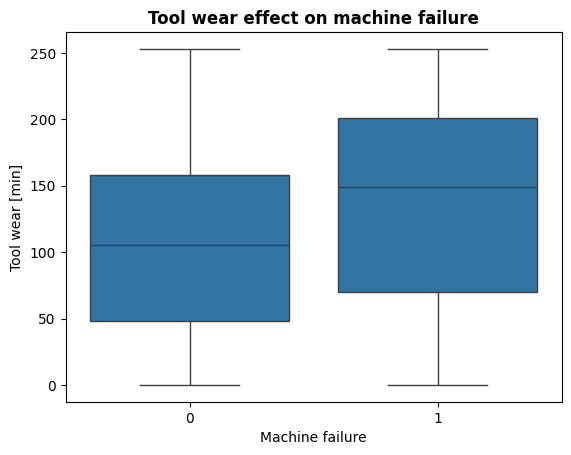

In [ ]:
sns.boxplot(x=train['Machine failure'],y=train['Tool wear [min]'])
plt.title('Tool wear effect on machine failure',weight='bold')
plt.show()

##### 1. Why did you pick the specific chart?

**To visualize the effect of total wear (in minutes) on machine failure**

##### 2. What is/are the insight(s) found from the chart?



1. **Machines that failed have higher median tool wear and wider spread** than those that didn't fail. We can say total wear is associated with machine failure.
2.  Failures rarely happen at lower total wear.



#### **Box Plot 2**

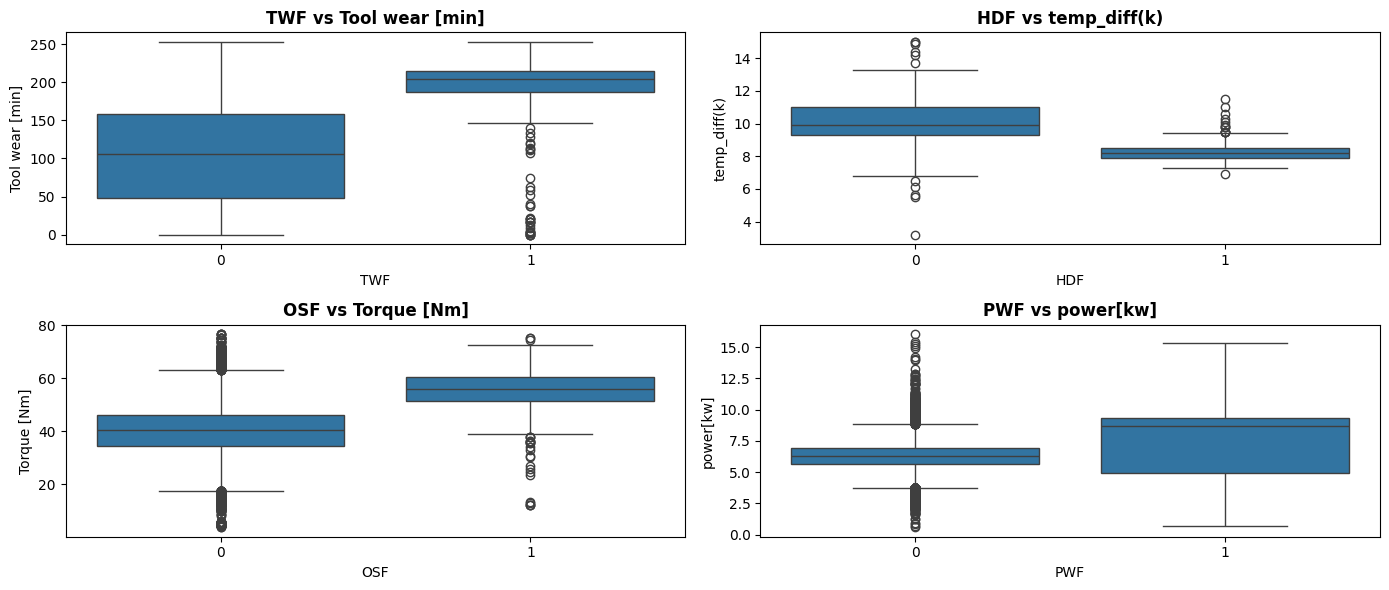

In [ ]:
cols = [['TWF','Tool wear [min]'],['HDF','temp_diff(k)'],['OSF','Torque [Nm]'],['PWF','power[kw]']]
fig,axes = plt.subplots(2,2,figsize=(14,6))
axes = axes.flatten()
for a,(i,j) in enumerate(cols):
  ax=axes[a]
  sns.boxplot(x=i,y=j,data=train,ax=ax)
  ax.set_title(f"{i} vs {j}",weight='bold')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

**To study the effect of feature on failure type**

##### 2. What is/are the insight(s) found from the chart?

**TWS VS TOTAL-WEAR**
1. Failure has higher tool wear (170-220 min) and a few lower-value outliers
2. Class 0 is widely spread
2. **Higer the Tool wear --> High probability of TWF**

**HDF VS TEMPERATURE DIFFERENCE**
1. Failures (HDF) have lower temperature difference (7-8 kelvin) and less spread

**OSF VS TORQUE**
1. Failures have higher Torque (50-65 Nm) when compared to class 0 (35-45 Nm).
2. **Higher Torque can cause overload and lead to machine failure.**

**PWF VS POWER**
1. There is an overlap between class 1 and class 0 wrt power. Failures have higher median Power (8-9 Kw).
2. **Power alone can not seperate machine failures from non-failures**



#### **Correlation Heatmap**

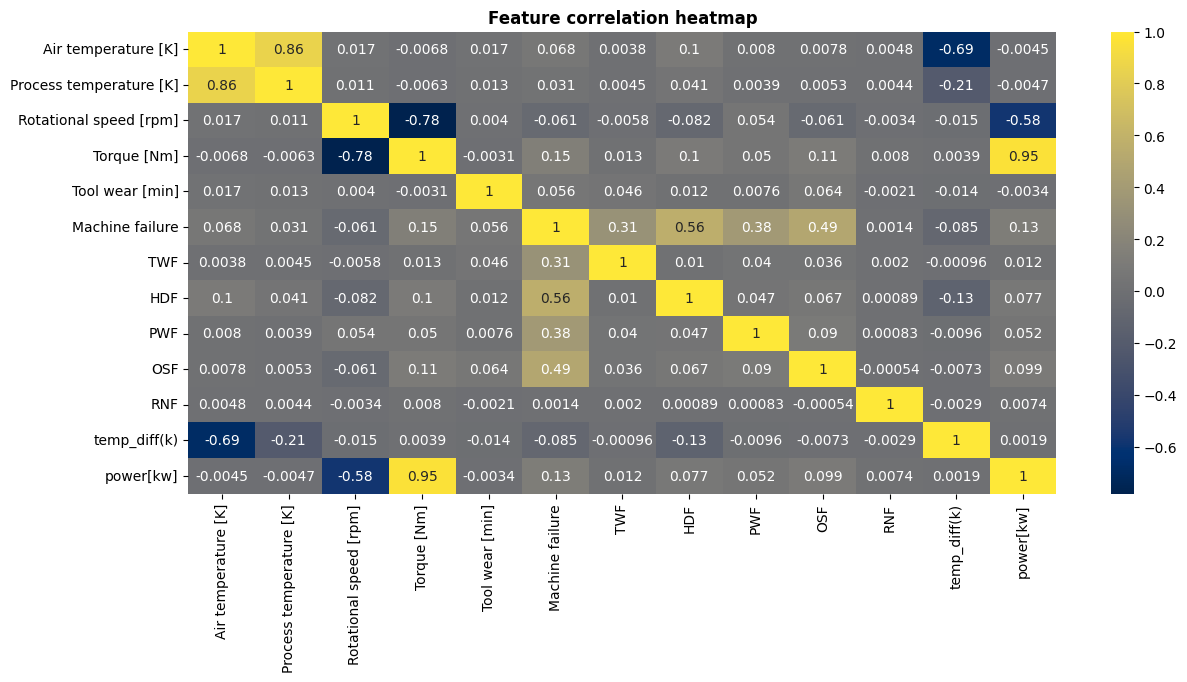

In [ ]:
corr = train.corr(numeric_only=True)
plt.figure(figsize=(14,6))
sns.heatmap(corr,annot=True,cmap="cividis")
plt.title("Feature correlation heatmap",weight='bold')
plt.show()

##### 1. Why did you pick the specific chart?

**To study the correlation between features**

##### 2. What is/are the insight(s) found from the chart?

1. Strong positive relation beween Process and Air temperature.
2. Strong negative relation between Torque and rotational speed. As speed increases, Torque decreases.
3. Machine Failure is dependent on (moderately) or driven by OSF,HDF,TSF,PWF.
4. Machine failure not driven by a single feature. It depends on combined effect of features.
5. **Non-linear models like Random Forest,XGBoost** might be useful not just logistic regression.



## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

1. **Effect of tool wear on machine failure.**
2. **Effect of Temperature or Temperature difference on machine failure.**
3. **Effect of Torque load on machine failure.**

### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

* **H0**:-Tool wear has the same distribution for machine failure and non-failure classes.
* **Ha**:- Tool wear is higher for the machine failure class.

#### 2. Perform an appropriate statistical test.

In [ ]:
from scipy.stats import mannwhitneyu
cond1= train['Machine failure']==1
cond2= train['Machine failure'] ==0
mf = train[cond1]['Tool wear [min]']
nmf = train[cond2]['Tool wear [min]']
statistic,p_val = mannwhitneyu(mf,nmf)
print("test statistic value: ",statistic)
print("p-value: ",p_val)

test statistic value:  181166743.5
p-value:  1.5257675493131835e-92


##### Which statistical test have you done to obtain P-Value?

* **Mann-Whitney U test is used to check weather Tool Wear median/distribution is same for classes 0 and 1**.
* **The p-value (1.53 x 10^-92) of the test is << 0.05. Therefore, we have strong evidence to reject the evidence to reject null hypothesis, and we can conclude that Tool wear is significantly higher for the Machine Failure class.**

##### Why did you choose the specific statistical test?

**Mann-Whitney U test (alternative to t-test in non-parametric tests) is used for data that does not assume any specific distribution. Here, Tool Wear is not normally distributed and a bit skewed to the right**

### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

* **H0**:- Mean Torque is same for failure and non-failures
* **Ha**:- Mean Torque is different (higher) for machine failures.

#### 2. Perform an appropriate statistical test.

In [ ]:
from scipy.stats import ttest_ind
mf = train[cond1]['Torque [Nm]']
nmf = train[cond2]['Torque [Nm]']

stat,p_value = ttest_ind(mf,nmf,equal_var=False)
print("test statistic value: ",stat)
print("p-value: ",p_value)

test statistic value:  34.6852558658905
p-value:  3.4244026041706776e-210


##### Which statistical test have you done to obtain P-Value?

1. **Welch's t-test is used to compare torque values for class 0 and class 1**.
2. **The p-value(3.42 x 10^-210) of the test is significantly lower than <<0.05. Therefore, we have strong evidence to reject the null hypothesis, and we can conclude that the torque value differs (higher) for the Machine Failure class.**
3. Although torque is statistically significant, it has a very low correlation with machine failure, suggesting that multiple interacting factors cause failure.

##### Why did you choose the specific statistical test?

**Welch's t-test is used when you know that the data is normally ditributed and varinace of two classes is unknown**

### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

1. **H0**:- Mean Process temperature is same for both classes(failure,non-failure)
2. **Ha**:- Mean process temperature is significantly different for each class.

#### 2. Perform an appropriate statistical test.

In [ ]:
mf = train[cond1]['Process temperature [K]']
nmf = train[cond2]['Process temperature [K]']

stat,p_value = ttest_ind(mf,nmf,equal_var=False)
print("test statistics value: ",stat)
print("p_value: ",p_value)

test statistics value:  12.591173274060116
p_value:  3.596941692933074e-35


##### Which statistical test have you done to obtain P-Value?

**Welch's t-test**
1. The p_value of the test is significantly lower than  << 0.05; therefore, we have enough evidence to reject the null hypothesis
2. Process temperature differs for both classes. Higher Process temperature is associated with machine failure. However, the relatively low correlation suggests that temperature has a moderate effect and contributes to machine failure in combination with other factors.

##### Why did you choose the specific statistical test?

Welch's test for Normally distributed data and unknown variance





## ***6.Data Pre-processing***

### 1. Handling Outliers

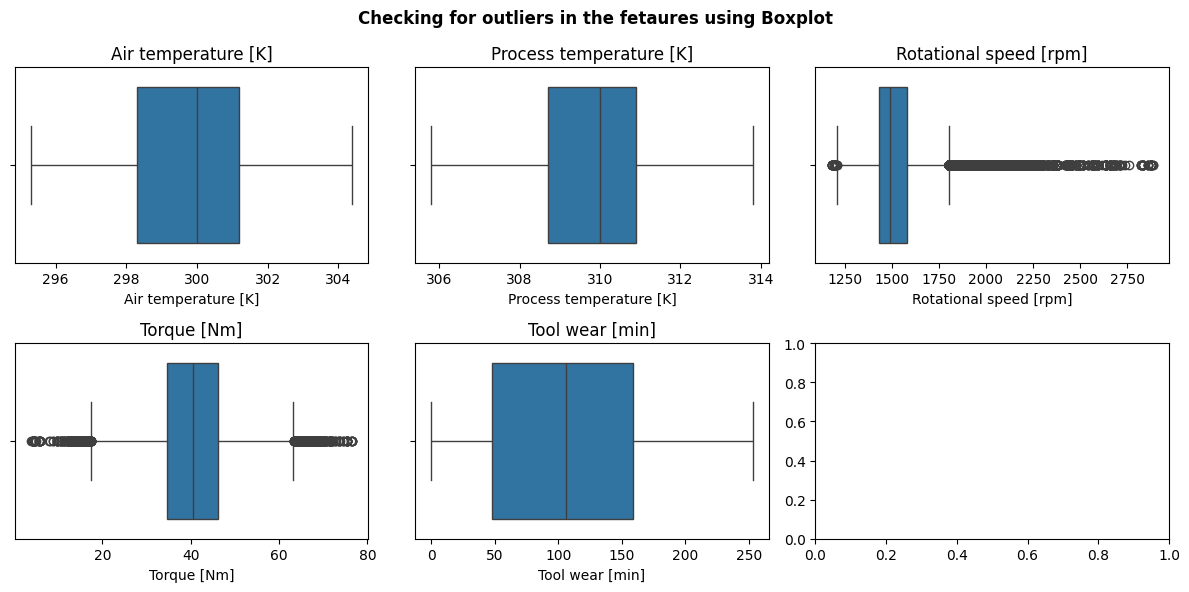

In [ ]:
##CHECKING FOR OUTLIERS

cols = ["Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"]
fig,axes = plt.subplots(2,3,figsize=(12,6))
axes = axes.flatten()
for i,j in enumerate(cols):
  sns.boxplot(x=train[j],ax=axes[i])
  axes[i].set_title(f"{j}")
plt.suptitle('Checking for outliers in the fetaures using Boxplot',weight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Handling Outliers & Outlier treatments

##### What all outlier treatment techniques have you used and why did you use those techniques?

1. **There are outliers Rotational speed and torque, these are not errors. They are linked to overstrain and power failure. Therefore we will not be removing these extreme values.**

### 2. Categorical Encoding

In [ ]:
# Encoding 'Type' feature
train['Type'] = train['Type'].map({'L':0,'M':1,'H':2})

In [ ]:
train.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,temp_diff(k),power[kw]
0,0,300.6,309.6,1596,36.1,140,0,0,0,0,0,0,9.0,6.03
1,1,302.6,312.1,1759,29.1,200,0,0,0,0,0,0,9.5,5.36
2,0,299.3,308.5,1805,26.5,25,0,0,0,0,0,0,9.2,5.01
3,0,301.0,310.9,1524,44.3,197,0,0,0,0,0,0,9.9,7.07
4,1,298.0,309.0,1641,35.4,34,0,0,0,0,0,0,11.0,6.08


#### What all categorical encoding techniques have you used & why did you use those techniques?

**Simple label encoding/Manual mapping of "TYPE" feature using "MAP" function**

### 3. Feature Selection

#### Feature Selection using Random Forest

In [ ]:
x= train.drop(['Machine failure','TWF','PWF','OSF','HDF','RNF'],axis=1)
y=train['Machine failure']

In [ ]:
x.shape, y.shape

((136429, 8), (136429,))

In [ ]:
x.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],temp_diff(k),power[kw]
0,0,300.6,309.6,1596,36.1,140,9.0,6.03
1,1,302.6,312.1,1759,29.1,200,9.5,5.36
2,0,299.3,308.5,1805,26.5,25,9.2,5.01
3,0,301.0,310.9,1524,44.3,197,9.9,7.07
4,1,298.0,309.0,1641,35.4,34,11.0,6.08


In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100,random_state=2501)
rf.fit(x,y)


RandomForestClassifier(random_state=2501)

In [ ]:
from sklearn.feature_selection import SelectFromModel
selector = SelectFromModel(rf,threshold='median')
x_selected = selector.transform(x)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


In [ ]:
x_selected.shape

(136429, 4)

In [ ]:
x.columns[selector.get_support()]

Index(['Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]',
       'power[kw]'],
      dtype='object')

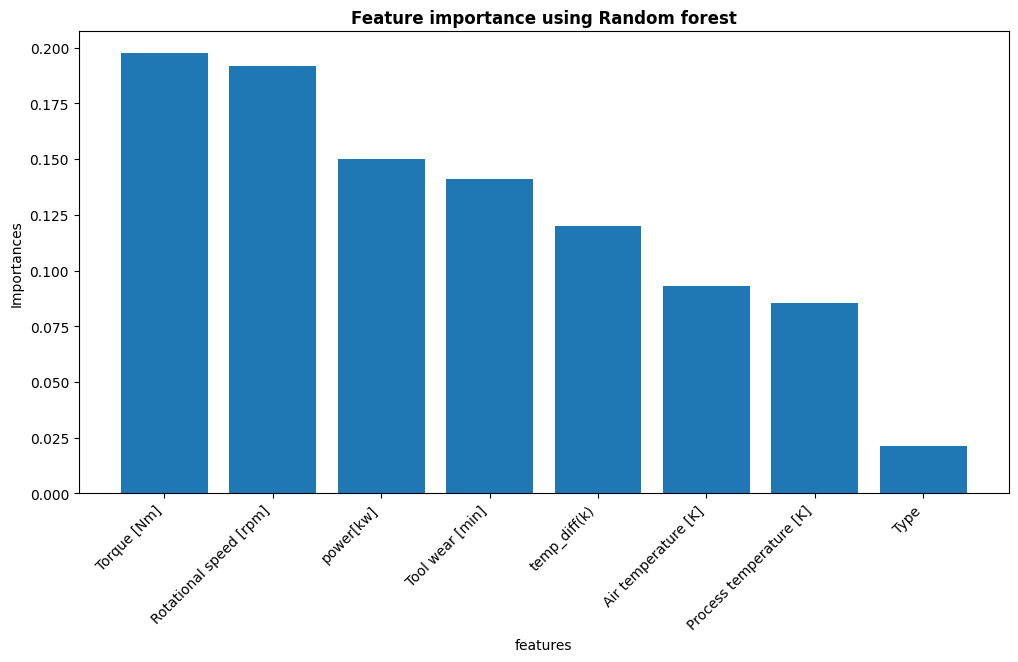

In [ ]:
###feature importance
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1] ##returns column position in descending column value order
sorted_features = x.columns[indices]

##plotting feature importance
plt.figure(figsize=(12,6))
plt.bar(range(len(importances)),importances[indices])
plt.xticks(range(len(importances)),sorted_features,rotation=45,ha='right')
plt.title("Feature importance using Random forest",weight='bold')
plt.xlabel("features")
plt.ylabel("Importances")
plt.show()

##### What all feature selection methods have you used  and why?

**RandomForestClassifier with SelectFromModel are used to select the important features. All the feature important values have been plotted above**

##### Which all features you found important and why?

1. **Since there are only 8 features available, we will not be doing any feature selection. All features will be included in the classification model training**:

2. **If we have to select, these are the top 4 featuress 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]','power[kw]'.**

### 5. Data Scaling

In [ ]:
# Scaling your data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x.drop(['Type'],axis=1))

In [ ]:
x_scal_df = pd.DataFrame(x_scaled,columns=x.columns[1:])
x_scal_df['Type'] = train['Type']

In [ ]:
x_scal_df.head()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],temp_diff(k),power[kw],Type
0,0.395880,-0.246230,0.545416,-0.499711,0.556417,-1.094793,-0.298429,0
1,1.469856,1.558605,1.720308,-1.323028,1.494433,-0.587143,-0.969638,1
2,-0.302204,-1.040358,2.051873,-1.628831,-1.241447,-0.891733,-1.320270,0
3,0.610675,0.692284,0.026445,0.464745,1.447532,-0.181023,0.743449,0
4,-1.000288,-0.679391,0.869773,-0.582043,-1.100744,0.935808,-0.248338,1


##### Which method have you used to scale you data and why?

1. **StandardScaler is used to scale the numerical columns; it uses the formula Z=(x-m)/sigma and brings down all the feature values between  "-1 to 1"**.
2. **Without scaling the dataset, larger-range features can dominate the model. Therefore, Scaling avoids this problem and is absolutely important for models like LogisticRegression, SVM, etc.,**

### 6. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

1. **Dimensionality reduction is used when there are too many features in the dataset. With the help of dimensionality reduction you combine the existing features into new ones, e.g., PCA**.

2. **For this dataset, dimensionality reduction is not required, cause there are only a few columns(8 features).**

### 7. Train-Test split

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x_scal_df,y,test_size=0.2,random_state=2501)

In [ ]:
x_train.shape,y_train.shape ##checking training data shape

((109143, 8), (109143,))

In [ ]:
##testing data shape
x_test.shape, y_test.shape

((27286, 8), (27286,))

In [ ]:
#modifying training column names
x_train.columns=(
    x_train.columns
    .str.replace('[', '', regex=False)
    .str.replace(']', '', regex=False)
    .str.replace('<', '', regex=False)
)

In [ ]:
x_train.head()

,Air temperature K,Process temperature K,Rotational speed rpm,Torque Nm,Tool wear min,temp_diff(k),powerkw,Type
122450,0.342182,1.197638,-0.384407,-0.041006,0.337547,1.037338,-0.178212,0
25390,-0.731794,-0.462811,0.552624,-0.429141,0.149943,0.732748,-0.188230,0
43705,2.060542,1.630798,-0.427654,0.029564,-0.162729,-1.602443,-0.118104,0
109917,-1.000288,-1.112551,0.624703,-0.793753,-1.116378,0.326627,-0.679115,0
116202,0.879169,0.475704,-0.261872,0.417699,-1.319615,-0.993263,0.492998,1


In [ ]:
##modifying test column names
x_test.columns=(
    x_test.columns
    .str.replace('[', '', regex=False)
    .str.replace(']', '', regex=False)
    .str.replace('<', '', regex=False)
)

In [ ]:
x_test.head()

,Air temperature K,Process temperature K,Rotational speed rpm,Torque Nm,Tool wear min,temp_diff(k),powerkw,Type
26411,-1.000288,-1.617905,1.828427,-1.558261,0.962890,-0.384083,-1.300234,1
107655,0.288483,0.620091,-0.305120,1.052829,0.415715,0.326627,1.304460,0
1097,0.449579,0.331317,-1.112408,1.417440,-0.100194,-0.384083,1.174225,0
132053,1.308759,1.342025,-1.112408,0.982259,-0.193996,-0.587143,0.643268,0
66800,0.825470,0.692284,-0.874546,1.005782,1.087959,-0.587143,0.833611,1


### 8. Handling Imbalanced Dataset

In [ ]:
# Handling Imbalanced Dataset
from imblearn.over_sampling import SMOTE
smt = SMOTE(random_state=2501)  ##smote model calling
x_smt,y_smt = smt.fit_resample(x_train,y_train)  ##data fitting

In [ ]:
x_smt.shape, y_smt.shape   ##shape after smote

((214862, 8), (214862,))

In [ ]:
y_smt.value_counts()   ##no class imabalance

,count
Machine failure,
0,107431
1,107431


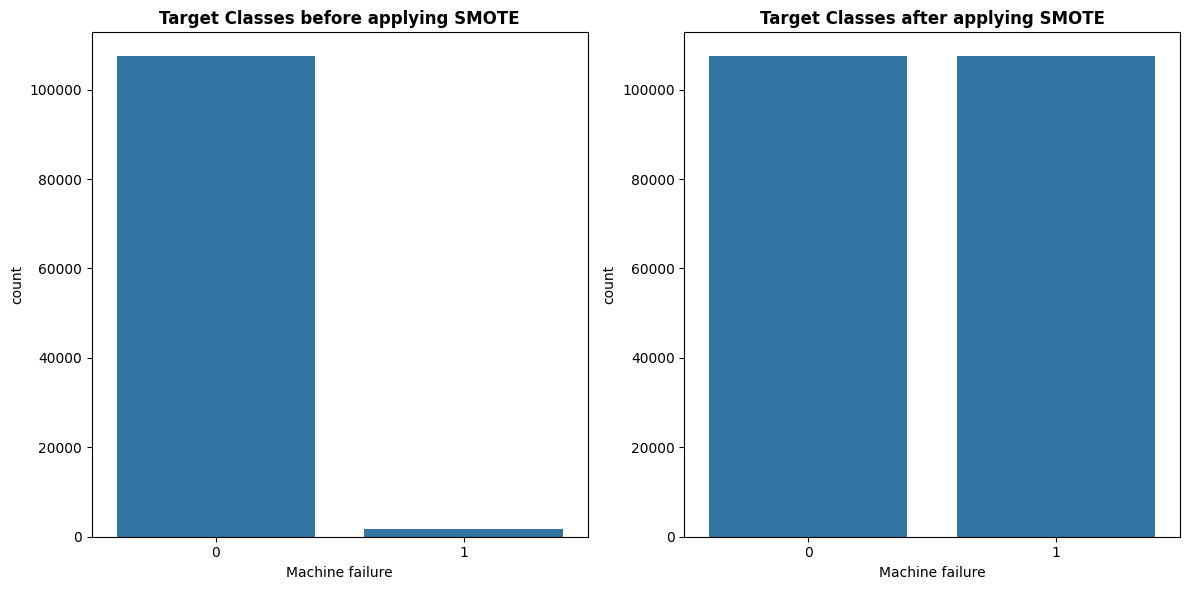

In [ ]:
fig,axes = plt.subplots(1,2,figsize=(12,6))
##before smote
sns.countplot(x=y_train,ax=axes[0])
axes[0].set_title('Target Classes before applying SMOTE',weight='bold')

##after smote
sns.countplot(x=y_smt,ax=axes[1])
axes[1].set_title('Target Classes after applying SMOTE',weight='bold')
plt.tight_layout()
plt.show()

##### What technique did you use to handle the imbalance dataset and why?

**SMOTE (Synthetic Minority Oversampling Technique), this oversampling technique uses a specialised geometric approach: it identifies K-nearest neighbours within the minority class and selects one of these points at random and then draws a line connecting to all other neighbours. It then places a synthetic datapoint on the line at a random location. This process is repeated until the minority class reaches a desired balance with the majority class.**

## ***7. ML Model Implementation***

### ML Model 1-  **LOGISTIC REGRESSION**

In [ ]:
# ML Model - 1 Implementation
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(class_weight='balanced',max_iter=100)
# Fit the Algorithm
lr.fit(x_smt,y_smt)
# Predict on the model
y_train_pred = lr.predict(x_smt)
y_test_pred = lr.predict(x_test)

1. **Logistic Regression is supervised machine learning algorithm used to predict the probability of a categorical outcome. Despite its name,it is primarily used for classification tasks --> determining which category a piece of data belongs to**
2. **The core goal of logisitic regression is to find a mathematical relationship between one or more independent feature variables and the categorical outcome/dependent variable.**

**FORMULA:**
* z=mx +c
* sigma(z) = 1/(1+e^-z) gives the probability

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [ ]:
# Visualizing evaluation Metric Score chart
from sklearn.metrics import f1_score,classification_report,confusion_matrix
cr = classification_report(y_test,y_test_pred) ## test data Classification report before thresholding
print("Test data Classification report before thresholding \n")
print(cr)

Test data Classification report before thresholding 

              precision    recall  f1-score   support

           0       1.00      0.83      0.91     26850
           1       0.07      0.77      0.13       436

    accuracy                           0.83     27286
   macro avg       0.53      0.80      0.52     27286
weighted avg       0.98      0.83      0.89     27286



####  **Training data classification report**

In [ ]:
###classification report training data
cr = classification_report(y_smt,y_train_pred)
print("Training data classification report \n")
print(cr)

Training data classification report 

              precision    recall  f1-score   support

           0       0.80      0.84      0.82    107431
           1       0.83      0.80      0.81    107431

    accuracy                           0.82    214862
   macro avg       0.82      0.82      0.82    214862
weighted avg       0.82      0.82      0.82    214862



####  **Test data CM, classification report**

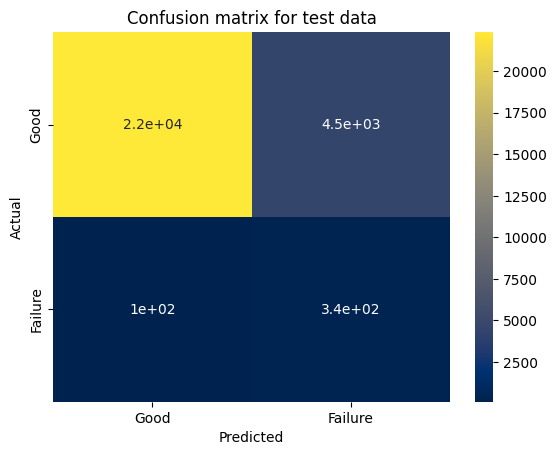

In [ ]:
cm = confusion_matrix(y_test,y_test_pred)
labels = ['Good','Failure']
sns.heatmap(cm,annot=True,cmap='cividis',xticklabels=labels,yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title("Confusion matrix for test data")
plt.show()

**A confusion matrix can be misleading in this case due to class imbalance in the test data.**

In [ ]:
###cr
cr = classification_report(y_test,y_test_pred)
print("Classification report of LR on test data \n")
print(cr)


Classification report of LR on test data 

              precision    recall  f1-score   support

           0       1.00      0.83      0.91     26850
           1       0.07      0.77      0.13       436

    accuracy                           0.83     27286
   macro avg       0.53      0.80      0.52     27286
weighted avg       0.98      0.83      0.89     27286



**Precision and recall values for class1 on test data are not good**

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV)
from sklearn.model_selection import GridSearchCV,StratifiedKFold
lr = LogisticRegression(class_weight='balanced')  ### logistic regression with class weight

##parameter grid
p_grid = {'max_iter':[50,75,100],
          'C':[0.1,1,10],
          'solver':['liblinear','lbfgs']}

## startifiedkfold
scv = StratifiedKFold(n_splits=5,shuffle=True,random_state=2501)

# Gridsearchcv Algorithm
gr = GridSearchCV(lr,param_grid=p_grid,cv=scv,scoring='f1',n_jobs=-1,error_score=np.nan)

##fitting the model on train data
gr.fit(x_train,y_train)
best_model = gr.best_estimator_ ##getting best model after cv
print("Best model",best_model)

# Predict on the model
y_cv_pred = best_model.predict(x_test)

Best model LogisticRegression(C=1, class_weight='balanced', max_iter=50)


In [ ]:
##CLASSIFICATION REPORT
cr = classification_report(y_test,y_cv_pred)
print("Classification report after GRIDSEARCHCV on test data")
print(cr)
print("\n EVEN AFTER CROSS VALIDAITON THERE NO IMPROVEMNT IN THE PRECISION RECALL SCORES OF CLASS1")

Classification report after GRIDSEARCHCV on test data
              precision    recall  f1-score   support

           0       1.00      0.83      0.90     26850
           1       0.07      0.77      0.12       436

    accuracy                           0.83     27286
   macro avg       0.53      0.80      0.51     27286
weighted avg       0.98      0.83      0.89     27286


 EVEN AFTER CROSS VALIDAITON THERE NO IMPROVEMNT IN THE PRECISION RECALL SCORES OF CLASS1


#### **Precision recall curve and thresholding**

In [ ]:
x_test.head()

,Air temperature K,Process temperature K,Rotational speed rpm,Torque Nm,Tool wear min,temp_diff(k),powerkw,Type
26411,-1.000288,-1.617905,1.828427,-1.558261,0.962890,-0.384083,-1.300234,1
107655,0.288483,0.620091,-0.305120,1.052829,0.415715,0.326627,1.304460,0
1097,0.449579,0.331317,-1.112408,1.417440,-0.100194,-0.384083,1.174225,0
132053,1.308759,1.342025,-1.112408,0.982259,-0.193996,-0.587143,0.643268,0
66800,0.825470,0.692284,-0.874546,1.005782,1.087959,-0.587143,0.833611,1


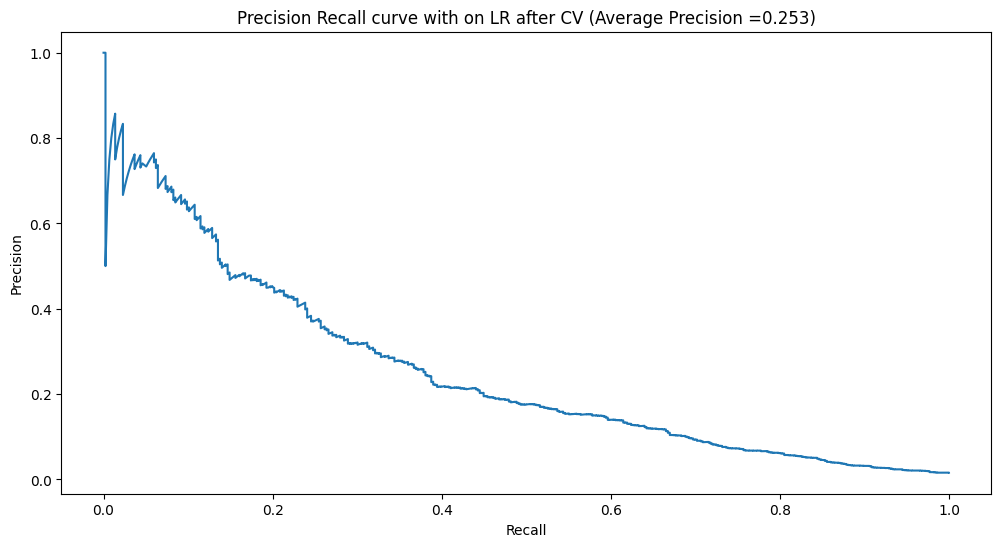

In [ ]:
##precision recall curve
from sklearn.metrics import precision_recall_curve,average_precision_score
y_lrproba = best_model.predict_proba(x_test)[:,1]  ### getting training probability values of class1

##computing PR values
p,r,th = precision_recall_curve(y_test,y_lrproba)

##average precision
avp = average_precision_score(y_test,y_lrproba)

###plotting curve
plt.figure(figsize=(12,6))
plt.plot(r,p)
plt.xlabel('Recall')
plt.ylabel("Precision")
plt.title(f"Precision Recall curve with on LR after CV (Average Precision ={avp:.3f})")
plt.show()

In [ ]:
##choosing best threshold
f1_scores=  2*(p*r)/(p+r+1e-10)
best_idx = np.argmax(f1_scores) ##returns the index of maximun f1_scores
best_threshold = th[best_idx]  ##returns best threshold
best_f1 = f1_scores[best_idx]

print("Best threshold: ",best_threshold)
print("Best F1: ",best_f1)

Best threshold:  0.8930466917775852
Best F1:  0.31627906971745157


In [ ]:
##classification report after thresholding
y_cv_pred1 = (y_lrproba>best_threshold).astype(int)
cr = classification_report(y_test,y_cv_pred1)
print("Classification report after applying threshold \n")
print(cr)
print("\n There is an imporvement in precision-recall after applying thresholding")


Classification report after applying threshold 

              precision    recall  f1-score   support

           0       0.99      0.99      0.99     26850
           1       0.32      0.31      0.31       436

    accuracy                           0.98     27286
   macro avg       0.65      0.65      0.65     27286
weighted avg       0.98      0.98      0.98     27286


 There is an imporvement in precision-recall after applying thresholding


##### Which hyperparameter optimization technique have you used and why?

**GridSearchCV is used for hyperparameter tuning, cause it uses all possible combinations of the parameters and gets best possible model/parameters.**

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

**There is no significant improvement in the model performance even after hyperparameter tuning. Precision-Recall scores of class1 remain the same. But there is an improvement after applying thresholds**

### ML Model 2 - XGBOOST

In [ ]:
from xgboost import XGBClassifier
xgb = XGBClassifier(random_state=2501,eval_metric="logloss") ##model calling

#3fitting training data
xgb.fit(x_smt,y_smt)

##  Prediction
y_xgb_pred = xgb.predict(x_test)

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

**XGBoost is a specialized ensemble machine learning algorithm based on decision trees. Instead of building one big tree, XGB builds many new weak decision trees sequentially, with each tree tries to correct the mistakes made by the previous trees. The finaly prediction is based on the combination of all trees.**

**Math behind XGBOOST**:

It minimizes error step-by-step using gradients.

**Loss_new** = (Loss_old) - (η∇Loss)

**Where:**

**η** = learning rate.

**∇Loss** = direction of error reduction

####  **Training data classification report**

In [ ]:
##training prediction
y_xgb_train = xgb.predict(x_smt)

In [ ]:
###classification report training data
cr = classification_report(y_smt,y_xgb_train)
print("Training data classification report \n")
print(cr)
print("\n Training precision-recall score of class1 and class0 are good")

Training data classification report 

              precision    recall  f1-score   support

           0       0.98      0.98      0.98    107431
           1       0.98      0.98      0.98    107431

    accuracy                           0.98    214862
   macro avg       0.98      0.98      0.98    214862
weighted avg       0.98      0.98      0.98    214862


 Training precision-recall score of class1 and class0 are good


####  **Test data CM, classification report**

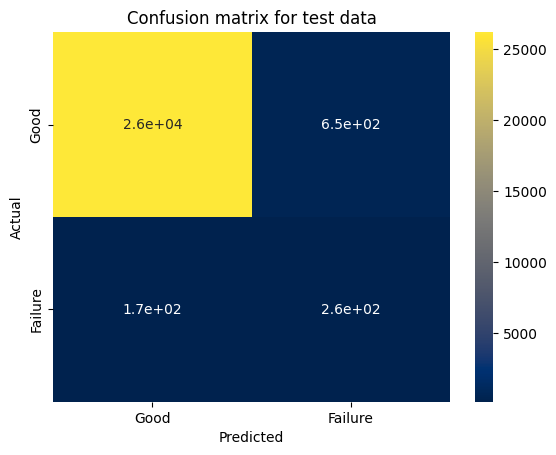

In [ ]:
cm = confusion_matrix(y_test,y_xgb_pred)
labels = ['Good','Failure']
sns.heatmap(cm,annot=True,cmap='cividis',xticklabels=labels,yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title("Confusion matrix for test data")
plt.show()

**A confusion matrix can be misleading in this case due to class imbalance in the test data.**

In [ ]:
##cr
cr = classification_report(y_test,y_xgb_pred)
print("Classification report of XGB on testdata\n")
print(cr)
print("\n f1 score is not good and very low precision score for class1")

Classification report of XGB on testdata

              precision    recall  f1-score   support

           0       0.99      0.98      0.98     26850
           1       0.29      0.61      0.39       436

    accuracy                           0.97     27286
   macro avg       0.64      0.79      0.69     27286
weighted avg       0.98      0.97      0.98     27286


 f1 score is not good and very low precision score for class1


#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (GridSearch CV)
p_gridx = {
    'n_estimators':[50,100],
    'max_depth' :[3,5,7],
    'learning_rate':[0.01,0.1,1],
    'colsample_bytree':[0.8,1.0]
}

grid_xgb = GridSearchCV(xgb,cv=scv,param_grid=p_gridx,scoring='f1',n_jobs=-1,error_score=np.nan)  ##gridsearch model

# Fit the Algorithm
grid_xgb.fit(x_smt,y_smt)

##best xgb model
best_xgb = grid_xgb.best_estimator_
print("best xgb model: ",best_xgb)

# Predict on the model
y_xcv_pred = best_xgb.predict(x_test)

best xgb model:  XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=7, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)


In [ ]:
##cr after gridsearch cv
cr = classification_report(y_test,y_xcv_pred)
print("Classification report after apply gridsearchcv for XGB\n")
print(cr)
print("\n After applying cross validation the f1score has imporved (but not significantly)")

Classification report after apply gridsearchcv for XGB

              precision    recall  f1-score   support

           0       0.99      0.99      0.99     26850
           1       0.37      0.52      0.43       436

    accuracy                           0.98     27286
   macro avg       0.68      0.75      0.71     27286
weighted avg       0.98      0.98      0.98     27286


 After applying cross validation the f1score has imporved (but not significantly)


#### **PR curve and thresholding**

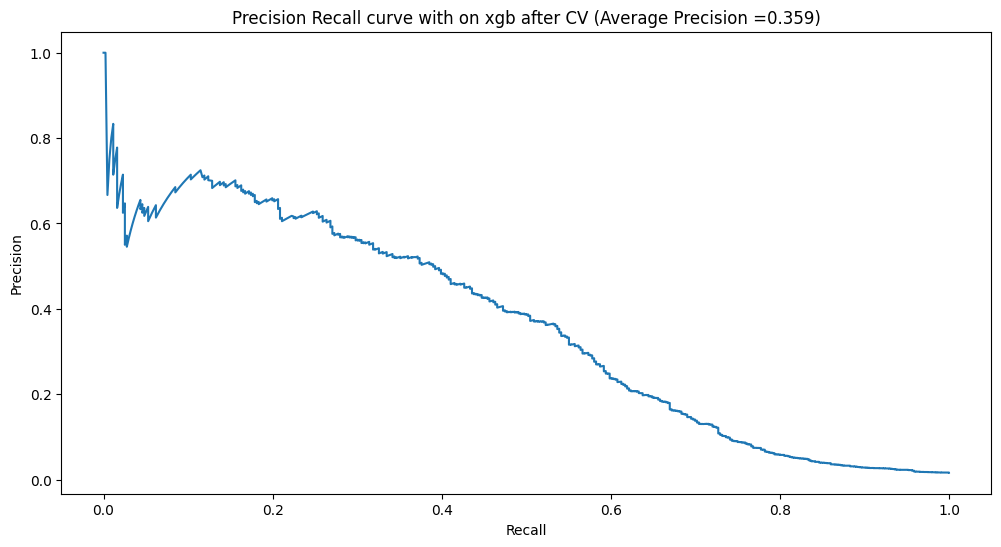

In [ ]:
y_xgbproba = best_xgb.predict_proba(x_test)[:,1]  ### getting training probability values of class1

##computing PR values
p,r,th = precision_recall_curve(y_test,y_xgbproba)

##average precision
avp = average_precision_score(y_test,y_xgbproba)

###plotting curve
plt.figure(figsize=(12,6))
plt.plot(r,p)
plt.xlabel('Recall')
plt.ylabel("Precision")
plt.title(f"Precision Recall curve with on xgb after CV (Average Precision ={avp:.3f})")
plt.show()

In [ ]:
##choosing best threshold
f1_scores=  2*(p*r)/(p+r+1e-10)
best_idx = np.argmax(f1_scores) ##returns the index of maximun f1_scores
best_threshold = th[best_idx]  ##returns best threshold
best_f1 = f1_scores[best_idx]

print("Best threshold: ",best_threshold)
print("Best F1: ",best_f1)

Best threshold:  0.7404256
Best F1:  0.4426229507696943


In [ ]:
##classification report after thresholding
y_xcv_pred1 = (y_xgbproba>best_threshold).astype(int)
cr = classification_report(y_test,y_cv_pred1)
print("Classification report for xgb after applying CV and thresholds \n")
print(cr)
print("\n There is no imporvement in f1_score after applying thresholds, F1 score decreased")


Classification report for xgb after applying CV and thresholds 

              precision    recall  f1-score   support

           0       0.99      0.99      0.99     26850
           1       0.32      0.31      0.31       436

    accuracy                           0.98     27286
   macro avg       0.65      0.65      0.65     27286
weighted avg       0.98      0.98      0.98     27286


 There is no imporvement in f1_score after applying thresholds, F1 score decreased


##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

**There is an improvement in the F1 score after applying GridSearchCV, but the improvement is not significant.**



### ML Model 3- RandomForestClassifier

In [ ]:
# ML Model - 3 Implementation
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100,random_state=2501)

# Fit the Algorithm
rf.fit(x_smt,y_smt)

# Predict on the model
y_rf_train_pred = rf.predict(x_smt)
y_rf_test_pred = rf.predict(x_test)

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

1. **RandomForest is another type of ensemble machine learning model based on decision tree. Unlike XGBOOST, RandomForest builds trees independently, performs prediction and then combines the predictions/Majority voting of all trees to get the final result.**
2. **Randomforest classifier reduces overfitting by using random samples of data and random subsets of features**

#### **Training Classification report**

In [ ]:
##code for cr
cr = classification_report(y_smt,y_rf_train_pred)
print("Classification report for RF on training data\n")
print(cr)
print("\n RF performs well on training data")

Classification report for RF on training data

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    107431
           1       1.00      1.00      1.00    107431

    accuracy                           1.00    214862
   macro avg       1.00      1.00      1.00    214862
weighted avg       1.00      1.00      1.00    214862


 RF performs well on training data


#### **Test data Classification report and CM**

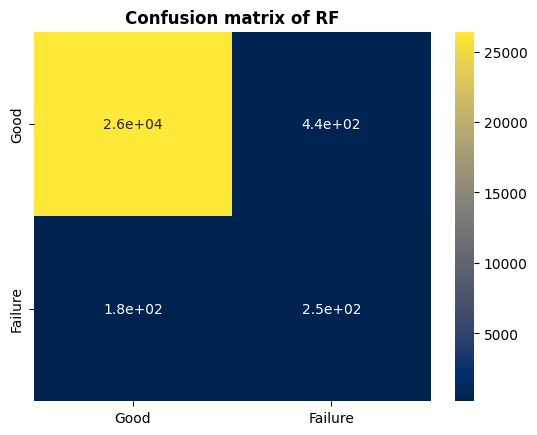


 CONFUSION MATRIX CAN BE MISLEADING


In [ ]:
### code for cm
cm = confusion_matrix(y_test,y_rf_test_pred)
labels=['Good','Failure']
sns.heatmap(cm,annot=True,xticklabels=labels,yticklabels=labels,cmap='cividis')
plt.title("Confusion matrix of RF",weight='bold')
plt.show()
print("\n CONFUSION MATRIX CAN BE MISLEADING")

In [ ]:
##code for cr
cr = classification_report(y_test,y_rf_test_pred)
print("Classification report of RF on test data \n")
print(cr)
print("\n Class1 has low F1 SCORE, but is better than XGBOOST and LR")

Classification report of RF on test data 

              precision    recall  f1-score   support

           0       0.99      0.98      0.99     26850
           1       0.37      0.58      0.45       436

    accuracy                           0.98     27286
   macro avg       0.68      0.78      0.72     27286
weighted avg       0.98      0.98      0.98     27286


 Class1 has low F1 SCORE, but is better than XGBOOST and LR


#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# ML Model - 3 Implementation with hyperparameter optimization techniques (GridSearch CV)
p_gridrf = {'n_estimators':[100],
            'max_depth':[3,5],
            'min_samples_split':[2,4],
            "min_samples_leaf":[1,2]}

# Fit the Algorithm
grid_rf = GridSearchCV(rf,param_grid=p_gridrf,scoring='f1',n_jobs=-1,cv=scv,error_score=np.nan)
grid_rf.fit(x_smt,y_smt)
best_rf = grid_rf.best_estimator_



In [ ]:
# Predict on the model
print("Best RF MODEL: ",best_rf)
y_rfcv_pred = best_rf.predict(x_test)

Best RF MODEL:  RandomForestClassifier(max_depth=5, min_samples_leaf=2, random_state=2501)


In [ ]:
##cr after CV
cr = classification_report(y_test,y_rfcv_pred)
print("Classificaton report for RF with Gridsearchcv \n")
print(cr)
print("\n  Class1 F1 score has reduced significantly after Crossvalidation")

Classificaton report for RF with Gridsearchcv 

              precision    recall  f1-score   support

           0       1.00      0.90      0.94     26850
           1       0.11      0.81      0.20       436

    accuracy                           0.89     27286
   macro avg       0.55      0.85      0.57     27286
weighted avg       0.98      0.89      0.93     27286


  Class1 F1 score has reduced significantly after Crossvalidation


#### **PR curve and thresholding**

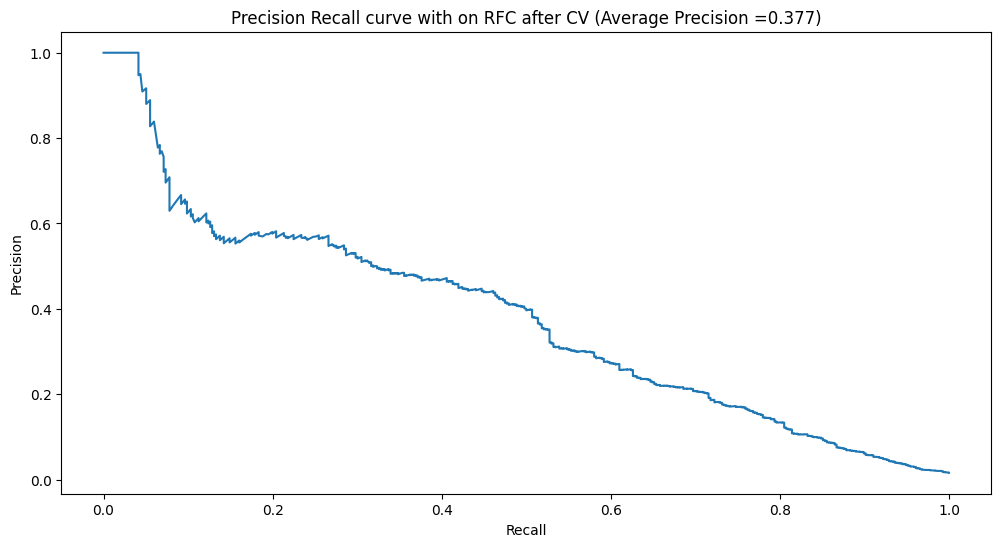

In [ ]:
y_rfcvproba = best_rf.predict_proba(x_test)[:,1]  ### getting training probability values of class1

##computing PR values
p,r,th = precision_recall_curve(y_test,y_rfcvproba)

##average precision
avp = average_precision_score(y_test,y_rfcvproba)

###plotting curve
plt.figure(figsize=(12,6))
plt.plot(r,p)
plt.xlabel('Recall')
plt.ylabel("Precision")
plt.title(f"Precision Recall curve with on RFC after CV (Average Precision ={avp:.3f})")
plt.show()

In [ ]:
##choosing best threshold
f1_scores=  2*(p*r)/(p+r+1e-10)
best_idx = np.argmax(f1_scores) ##returns the index of maximun f1_scores
best_threshold = th[best_idx]  ##returns best threshold
best_f1 = f1_scores[best_idx]

print("Best threshold: ",best_threshold)
print("Best F1: ",best_f1)

Best threshold:  0.8490518661294695
Best F1:  0.4511784511284739


In [ ]:
##classification report after thresholding
y_rfcv_pred1 = (y_rfcvproba>best_threshold).astype(int)
cr = classification_report(y_test,y_rfcv_pred1)
print("Classification report for RFC after applying CV and thresholds \n")
print(cr)
print("\n After Gridsearch + Thresholding there is a balance in precision,recall and f1score, but no significant improvement. These scores are similar to simple RFC")


Classification report for RFC after applying CV and thresholds 

              precision    recall  f1-score   support

           0       0.99      0.99      0.99     26850
           1       0.44      0.46      0.45       436

    accuracy                           0.98     27286
   macro avg       0.72      0.72      0.72     27286
weighted avg       0.98      0.98      0.98     27286


 After Gridsearch + Thresholding there is a balance in precision,recall and f1score, but no significant improvement. These scores are similar to simple RFC


##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

**RFC has produced an F1 score, higher than xgboost and Logistic regression. But cross-validation did not yield good results.**

### ML MODEL 4-SVM

In [ ]:
from sklearn.svm import LinearSVC
svm = LinearSVC(random_state=2501,max_iter=5000)  ##model calling
svm.fit(x_smt,y_smt)   ##svm training

LinearSVC(max_iter=5000, random_state=2501)

**SVM (Support Vector Machine) is a powerful classification algorithm that tries to find a best possible boundary (Hyperplane) seperating classes i.e. SVM tries to maximise the margin between two classes**

#### **Training Classification report**

In [ ]:
y_svm_train = svm.predict(x_smt)

In [ ]:
cr = classification_report(y_smt,y_svm_train)
print("classification report for SVM on training data\n")
print(cr)
print("\n Model performs well on the training data")

classification report for SVM on training data

              precision    recall  f1-score   support

           0       0.80      0.84      0.82    107431
           1       0.83      0.79      0.81    107431

    accuracy                           0.82    214862
   macro avg       0.82      0.82      0.82    214862
weighted avg       0.82      0.82      0.82    214862


 Model performs well on the training data


#### **Test data Classification report and confusion matrix**

In [ ]:
##performing prediction
y_svm_test = svm.predict(x_test)

In [ ]:
##code for classification report
cr = classification_report(y_test,y_svm_test)
print("Classification report for SVM on test data\n")
print(cr)
print("\n Precision and f1score for SVM on test data are very low")

Classification report for SVM on test data

              precision    recall  f1-score   support

           0       1.00      0.84      0.91     26850
           1       0.07      0.76      0.13       436

    accuracy                           0.84     27286
   macro avg       0.53      0.80      0.52     27286
weighted avg       0.98      0.84      0.90     27286





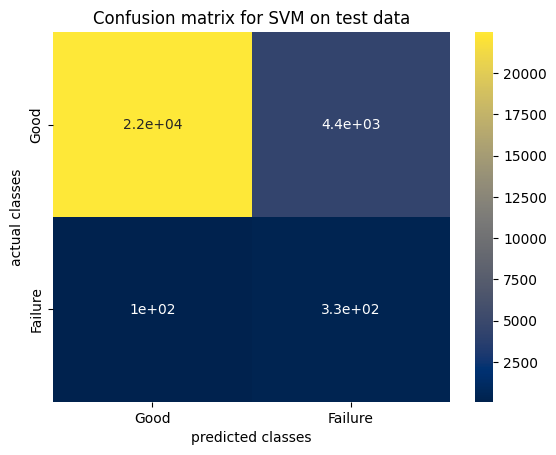


 Even though we have higher scores for class0, class1 is not well identified/predicted by the model. So, the Confusion matrix is misleading


In [ ]:
##confusion matrix
cm = confusion_matrix(y_test,y_svm_test)
labels = ['Good','Failure']
sns.heatmap(cm,annot=True,cmap='cividis',xticklabels=labels,yticklabels=labels)
plt.title("Confusion matrix for SVM on test data")
plt.xlabel('predicted classes')
plt.ylabel("actual classes")
plt.show()
print("\n Even though we have higher scores for class0, class1 is not well identified/predicted by the model. So, the Confusion matrix is misleading")

#### **Cross Validation using Gridsearchcv**

In [ ]:
p_gridsvm = {'C':[0.1,10],
             'max_iter':[5000,10000]}
## implentatiton
grid_svm = GridSearchCV(svm,param_grid=p_gridsvm,cv=scv,scoring='f1',error_score=np.nan,n_jobs=-1)

##fitting the data
grid_svm.fit(x_smt,y_smt)

##bestmodel
best_svm = grid_svm.best_estimator_


In [ ]:
print(best_svm)

LinearSVC(C=10, max_iter=5000, random_state=2501)


In [ ]:
##prediction
y_gridsvm = best_svm.predict(x_test)

In [ ]:
##classification report after gridsearchcv
cr = classification_report(y_test,y_gridsvm)
print("Classification report for SVM + GRIDSEARCH on test data\n")
print(cr)
print("\n This Classification report is same as Simple SVM report")

Classification report for SVM + GRIDSEARCH on test data

              precision    recall  f1-score   support

           0       1.00      0.84      0.91     26850
           1       0.07      0.76      0.13       436

    accuracy                           0.84     27286
   macro avg       0.53      0.80      0.52     27286
weighted avg       0.98      0.84      0.90     27286


 This Classification report is same as Simple SVM report


**Grid search CV did not yield good results for SVM**

##  8. ***Which ML model did you choose from the above created models as your final prediction model and why?***

1. **Among all the classification models evaluated, Random Forest with threshold tuning demonstrated the best overall performance. The model achieved a comparatively better balance between Precision and Recall, resulting in the highest F1-score among the evaluated models. Although the Precision, Recall, and F1-score values were approximately 40%, they consistently outperformed the corresponding metrics obtained from XGBoost, Support Vector Machine, and Logistic Regression.**

2. **Classification report for stage1 RFC after applying GridsearchCV and thresholds**

              precision    recall  f1-score   support

           0       0.99      0.99      0.99     26850
           1       0.44      0.46      0.45       436


## ***9. STAGE 2 OF ML MODEL IMPLEMENTATION:- Failure Type Classification***

#### **DATA PREPROCESSING**

In [ ]:
##FAILUR CLASSIFICATION CODE
def class_failure(row):
  if row['Machine failure'] ==0:
    return 'Good'
  elif row['TWF']==1:
    return 'TWF'
  elif row['OSF']==1:
    return 'OSF'
  elif row['HDF'] ==1:
    return 'HDF'
  elif row['PWF'] ==1:
    return 'PWF'
  elif row['RNF'] ==1:
    return 'RNF'

In [ ]:
train['failure type'] = train.apply(class_failure,axis=1) ## applying the function on the dataframe

In [ ]:
train.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,temp_diff(k),power[kw],failure type
0,0,300.6,309.6,1596,36.1,140,0,0,0,0,0,0,9.0,6.03,Good
1,1,302.6,312.1,1759,29.1,200,0,0,0,0,0,0,9.5,5.36,Good
2,0,299.3,308.5,1805,26.5,25,0,0,0,0,0,0,9.2,5.01,Good
3,0,301.0,310.9,1524,44.3,197,0,0,0,0,0,0,9.9,7.07,Good
4,1,298.0,309.0,1641,35.4,34,0,0,0,0,0,0,11.0,6.08,Good


In [ ]:
train_cf = train.drop(['TWF','OSF','RNF','PWF','HDF','Machine failure'],axis=1) ##droping columns with no that are not imporatant

In [ ]:
train_cf.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],temp_diff(k),power[kw],failure type
0,0,300.6,309.6,1596,36.1,140,9.0,6.03,Good
1,1,302.6,312.1,1759,29.1,200,9.5,5.36,Good
2,0,299.3,308.5,1805,26.5,25,9.2,5.01,Good
3,0,301.0,310.9,1524,44.3,197,9.9,7.07,Good
4,1,298.0,309.0,1641,35.4,34,11.0,6.08,Good


In [ ]:
print(train_cf['failure type'].value_counts())
print("\n THERE IS CLASS IMBALANCE IN THE DATASET")

failure type
Good    134281
HDF        650
OSF        523
PWF        255
TWF        212
RNF          1
Name: count, dtype: int64

 THERE IS CLASS IMBALANCE IN THE DATASET


In [ ]:
##REMOVING RNF, NOT required
cond = train_cf['failure type']=='RNF'

In [ ]:
train_cf = train_cf[~cond]

In [ ]:
train_cf['failure type'].value_counts()

,count
failure type,
Good,134281
HDF,650
OSF,523
PWF,255
TWF,212


In [ ]:
train_cf['failure type'].unique()  ##there are null values

array(['Good', None, 'HDF', 'OSF', 'TWF', 'PWF'], dtype=object)

In [ ]:
train_cf.dropna(inplace=True)  ##dropping null rows

In [ ]:
train_cf['failure type'].unique()  ##checking

array(['Good', 'HDF', 'OSF', 'TWF', 'PWF'], dtype=object)

In [ ]:
##removing good/no failures
cond = train_cf['failure type'] =='Good'
train_cf = train_cf[~cond]

In [ ]:
train_cf.shape ##checking

(1640, 9)

In [ ]:
train_cf['failure type'].value_counts()

,count
failure type,
HDF,650
OSF,523
PWF,255
TWF,212


In [ ]:
##dependent variable and features
x2=train_cf.drop(['failure type'],axis=1)
y2=train_cf['failure type']

In [ ]:
##checking shapes
x2.shape,y2.shape

((1640, 8), (1640,))

In [ ]:
##mapping target variable to numeric values

y2 = y2.map({
    'Good':0,
    'TWF':1,
    'OSF':2,
    'HDF':3,
    'PWF':4
})

In [ ]:
##CHECKING Y2
y2.value_counts()

,count
failure type,
3,650
2,523
4,255
1,212


In [ ]:
y2.unique()

array([3, 2, 1, 4])

In [ ]:
##TRAIN TEST SPLITTING
x2_train,x2_test,y2_train,y2_test = train_test_split(x2,y2,test_size=0.2,random_state=2501,stratify=y2)

In [ ]:
##training shapes
x2_train.shape, y2_train.shape

((1312, 8), (1312,))

In [ ]:
##test data shapes
x2_test.shape, y2_test.shape

((328, 8), (328,))

In [ ]:
##handling class imbalances using smote
x2_train_smt,y2_train_smt = smt.fit_resample(x2_train,y2_train)

In [ ]:
##checking shapes
x2_train_smt.shape,y2_train_smt.shape

((2080, 8), (2080,))

In [ ]:
y2_train_smt.value_counts()

,count
failure type,
1,520
3,520
2,520
4,520


#### **RFC MODEL TRAINING**

In [ ]:
rfc2 = RandomForestClassifier(class_weight='balanced',n_estimators=100,random_state=2501)
###fitting the data
rfc2.fit(x2_train_smt,y2_train_smt)

RandomForestClassifier(class_weight='balanced', random_state=2501)

#### **Training classification report**

In [ ]:
##prediction
y2_train_pred = rfc2.predict(x2_train_smt)

cr = classification_report(y2_train_smt,y2_train_pred)
print("Classification report for RFC2 on training data\n")
print(cr)
print('\n Training done successfully and no underfitting')

Classification report for RFC2 on training data

              precision    recall  f1-score   support

           1       0.99      1.00      1.00       520
           2       1.00      0.99      0.99       520
           3       1.00      1.00      1.00       520
           4       1.00      1.00      1.00       520

    accuracy                           1.00      2080
   macro avg       1.00      1.00      1.00      2080
weighted avg       1.00      1.00      1.00      2080


 Training done successfully and no underfitting


#### **Test data classification report**

In [ ]:
##prediction
y2_test_pred = rfc2.predict(x2_test)

##code for cr
cr = classification_report(y2_test,y2_test_pred)
print("classification report for RFC2 on test data\n")
print(cr)
print("\n Model does well on test data when compared to stage1 testing")

classification report for RFC2 on test data

              precision    recall  f1-score   support

           1       0.59      0.48      0.53        42
           2       0.69      0.70      0.69       105
           3       0.84      0.88      0.86       130
           4       0.73      0.73      0.73        51

    accuracy                           0.75       328
   macro avg       0.71      0.70      0.70       328
weighted avg       0.74      0.75      0.74       328


 Model does well on test data when compared to stage1 testing


**RFC2 produced good results, the f1 scores are very moderate for class1 (53%) and class2(69%) and good for classes 3(86%) and 4(73%). The model put some of its learnings into the test data**

#### **HYPERPARAMETER TUNING:- GRIDSEARCHCV WTIH RFC2**

In [ ]:
##parameters
p_grid2 ={
    'n_estimators':[100],
    'max_depth':[3,5],
    "min_samples_split":[2,4],
    'min_samples_leaf':[1,2]}

###Gridsearchcv
grid2 = GridSearchCV(rfc2,cv=5,scoring='f1_weighted',param_grid=p_grid2,n_jobs=-1,error_score=np.nan)

##fitting
grid2.fit(x2_train_smt,y2_train_smt)

##best model
best_rfc2 = grid2.best_estimator_
print('best model: ',best_rfc2)

best model:  RandomForestClassifier(class_weight='balanced', max_depth=5, min_samples_leaf=2,
                       random_state=2501)


In [ ]:
###prediction
y2_cv_pred = best_rfc2.predict(x2_test)

##classification report
cr = classification_report(y2_test,y2_cv_pred)
print("classification report of RFC2 WITH GRIDSEARCHCV on test data \n")
print(cr)
print("\n Low scores for classes 1,2,3,4" )

classification report of RFC2 WITH GRIDSEARCHCV on test data 

              precision    recall  f1-score   support

           1       0.67      0.57      0.62        42
           2       0.69      0.62      0.65       105
           3       0.82      0.89      0.86       130
           4       0.67      0.75      0.70        51

    accuracy                           0.74       328
   macro avg       0.71      0.71      0.71       328
weighted avg       0.74      0.74      0.74       328


 Low scores for classes 1,2,3,4


**Hyperparameter tuning using Gridsearchcv produced balanced precision, recall scores of all classes and improved f1score of class1**

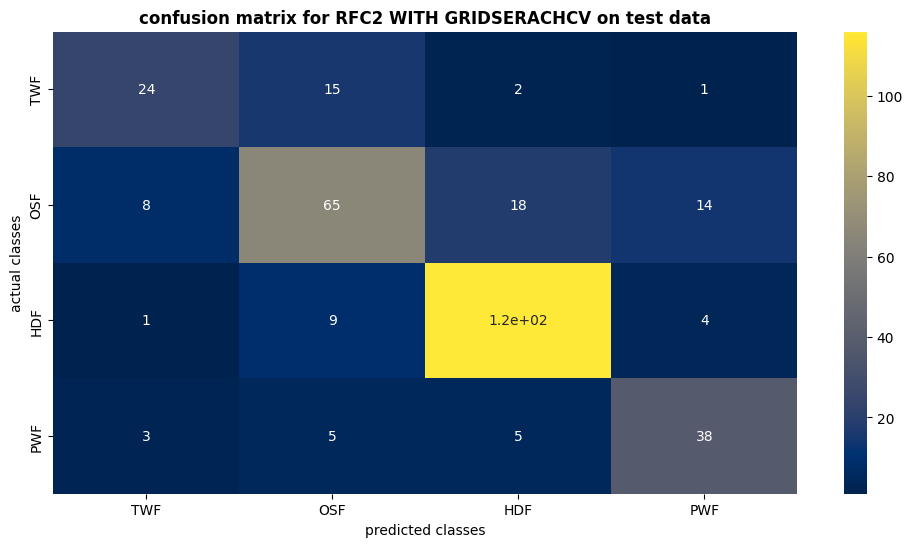

In [ ]:
###confusion matrix
cm = confusion_matrix(y2_test,y2_cv_pred)
plt.figure(figsize=(12,6))
labels =['TWF','OSF','HDF','PWF']
sns.heatmap(cm,annot=True,cmap='cividis',xticklabels=labels,yticklabels=labels)
plt.title("confusion matrix for RFC2 WITH GRIDSERACHCV on test data",weight='bold')
plt.xlabel('predicted classes')
plt.ylabel('actual classes')
plt.show()

## ***10. Explain the model which you have used and the feature importance***

**STAGE1**

1. This project implemented a two-stage predictive maintenance framework for industrial machine failure analysis using Random Forest as the primary classification model. In Stage-1, the objective was to predict whether a machine failure would occur, where multiple machine learning models including XGBoost, Support Vector Machine, Logistic Regression, and Random Forest were evaluated. Due to severe class imbalance, SMOTE and custom threshold tuning were applied to improve minority-class detection. Among all models, Random Forest with thresholding achieved the best balance between Precision, Recall, and F1-score, making it the most effective model for failure prediction.

2. Random Forest was particularly suitable for this project because the dataset contained complex and nonlinear relationships between process parameters and failure conditions. Unlike linear models, Random Forest can effectively capture feature interactions and hidden patterns without requiring extensive feature engineering.

3. To interpret the model and understand which features contributed most to predictions, feature importance analysis was performed using the built-in feature importance capability of Random Forest. This explainability method measures how much each feature contributes to reducing impurity across all trees in the forest.

4. The analysis showed that sensor-related and process-related variables had the highest influence on failure prediction. Features with higher importance scores contributed more significantly to identifying abnormal operating conditions and potential failures. This helped in understanding the key operational parameters affecting the target variable and improved the interpretability of the model.

5. Feature importance visualization was also used to rank the most influential features, enabling easier interpretation of the model's decision-making process and providing insights into the critical factors driving failures in the system.

**STAGE2**

1. In Stage-2, only records corresponding to machine failures were retained, and the model was trained to classify different failure types such as Tool Wear Failure, Heat Dissipation Failure, Power Failure, and Overstrain Failure. Removing the dominant “No Failure” class significantly improved multiclass learning performance. After applying SMOTE and hyperparameter tuning using GridSearchCV, the Random Forest classifier achieved an overall accuracy of 74% with a macro-average F1-score of 71%. The model demonstrated particularly strong performance in identifying HDF, achieving an F1-score of 86%.

## ***11.*** ***Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.


In [ ]:
# Save the File
import joblib
joblib.dump(best_rf,"stage1_bestrf_model.pkl")
joblib.dump(best_rfc2,"stage2_bestrf_model.pkl")
joblib.dump(scaler,"scaler.pkl")
joblib.dump(smt,"smote.pkl")

['smote.pkl']

### 2. Again Load the saved model file and try to predict unseen data for a sanity check.


In [ ]:
# Load the File and predict unseen data.
rfc1 = joblib.load("/content/drive/MyDrive/M6/stage1_bestrf_model.pkl")
rfc2 = joblib.load("/content/drive/MyDrive/M6/stage2_bestrf_model.pkl")

#### **unseen data preprocessing stage1 and prediction**

In [ ]:
rfc1,rfc2

(RandomForestClassifier(max_depth=5, min_samples_leaf=2, random_state=2501),
 RandomForestClassifier(class_weight='balanced', max_depth=5, min_samples_leaf=2,
                        random_state=2501))

In [ ]:
unseen = pd.read_csv("/content/drive/MyDrive/M6/test.csv")

In [ ]:
unseen.head()

,id,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],TWF,HDF,PWF,OSF,RNF
0,136429,L50896,L,302.3,311.5,1499,38.0,60,0,0,0,0,0
1,136430,L53866,L,301.7,311.0,1713,28.8,17,0,0,0,0,0
2,136431,L50498,L,301.3,310.4,1525,37.7,96,0,0,0,0,0
3,136432,M21232,M,300.1,309.6,1479,47.6,5,0,0,0,0,0
4,136433,M19751,M,303.4,312.3,1515,41.3,114,0,0,0,0,0


In [ ]:
unseen1 = unseen.drop(['id','Product ID','TWF','OSF','HDF','PWF','RNF','Type'],axis=1)

In [ ]:
unseen1.head()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
0,302.3,311.5,1499,38.0,60
1,301.7,311.0,1713,28.8,17
2,301.3,310.4,1525,37.7,96
3,300.1,309.6,1479,47.6,5
4,303.4,312.3,1515,41.3,114


In [ ]:
##feature engineering1
unseen1['power[kw]'] = round((unseen1['Torque [Nm]']* unseen1['Rotational speed [rpm]'])/9548.8,2)

In [ ]:
##feature enginering2
unseen1['temp_diff(k)'] = unseen1['Process temperature [K]'] * unseen1['Air temperature [K]']

In [ ]:
##label encoding
unseen1['Type'] = unseen['Type'].map({'L':0,'M':1,'H':2})

In [ ]:
unseen1.columns = (unseen1.columns
                   .str.replace('[','',regex=False)
                   .str.replace(']','',regex=False)
                   .str.replace('<','',regex=False))

In [ ]:
unseen1.head()

,Air temperature K,Process temperature K,Rotational speed rpm,Torque Nm,Tool wear min,powerkw,temp_diff(k),Type
0,302.3,311.5,1499,38.0,60,5.97,94166.45,0
1,301.7,311.0,1713,28.8,17,5.17,93828.70,0
2,301.3,310.4,1525,37.7,96,6.02,93523.52,0
3,300.1,309.6,1479,47.6,5,7.37,92910.96,1
4,303.4,312.3,1515,41.3,114,6.55,94751.82,1


In [ ]:
##loading scaler
scaler = joblib.load("/content/drive/MyDrive/M6/scaler.pkl")

In [ ]:
##scaling
unseen1_scal =scaler.fit_transform(unseen1)

In [ ]:
###prediction
stage1_pred = rfc1.predict(unseen1_scal)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [ ]:
unseen1['prediction stage1'] = stage1_pred

In [ ]:
unseen1.head()

,Air temperature K,Process temperature K,Rotational speed rpm,Torque Nm,Tool wear min,powerkw,temp_diff(k),Type,prediction stage1
0,302.3,311.5,1499,38.0,60,5.97,94166.45,0,0
1,301.7,311.0,1713,28.8,17,5.17,93828.70,0,0
2,301.3,310.4,1525,37.7,96,6.02,93523.52,0,0
3,300.1,309.6,1479,47.6,5,7.37,92910.96,1,0
4,303.4,312.3,1515,41.3,114,6.55,94751.82,1,0


#### **unseen stage2 prediction**

In [ ]:
unseen.head()

,id,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],TWF,HDF,PWF,OSF,RNF
0,136429,L50896,L,302.3,311.5,1499,38.0,60,0,0,0,0,0
1,136430,L53866,L,301.7,311.0,1713,28.8,17,0,0,0,0,0
2,136431,L50498,L,301.3,310.4,1525,37.7,96,0,0,0,0,0
3,136432,M21232,M,300.1,309.6,1479,47.6,5,0,0,0,0,0
4,136433,M19751,M,303.4,312.3,1515,41.3,114,0,0,0,0,0


In [ ]:
unseen2 = unseen.drop(['id','Product ID','TWF','OSF','HDF','PWF','RNF'],axis=1)

In [ ]:
unseen2['Type'] = unseen2['Type'].map({'L':0,'M':1,'H':2})

In [ ]:
unseen2.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
0,0,302.3,311.5,1499,38.0,60
1,0,301.7,311.0,1713,28.8,17
2,0,301.3,310.4,1525,37.7,96
3,1,300.1,309.6,1479,47.6,5
4,1,303.4,312.3,1515,41.3,114


In [ ]:
##feature enginering2
unseen2['temp_diff(k)'] = unseen['Process temperature [K]'] * unseen['Air temperature [K]']

In [ ]:
##feature engineering1
unseen2['power[kw]'] = round((unseen['Torque [Nm]']* unseen['Rotational speed [rpm]'])/9548.8,2)

In [ ]:
unseen2.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],temp_diff(k),power[kw]
0,0,302.3,311.5,1499,38.0,60,94166.45,5.97
1,0,301.7,311.0,1713,28.8,17,93828.70,5.17
2,0,301.3,310.4,1525,37.7,96,93523.52,6.02
3,1,300.1,309.6,1479,47.6,5,92910.96,7.37
4,1,303.4,312.3,1515,41.3,114,94751.82,6.55


In [ ]:
stage2_pred = rfc2.predict(unseen2)

In [ ]:
unseen2['stage2 prediction'] = stage2_pred

In [ ]:
unseen2.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],temp_diff(k),power[kw],stage2 prediction
0,0,302.3,311.5,1499,38.0,60,94166.45,5.97,1
1,0,301.7,311.0,1713,28.8,17,93828.70,5.17,1
2,0,301.3,310.4,1525,37.7,96,93523.52,6.02,1
3,1,300.1,309.6,1479,47.6,5,92910.96,7.37,1
4,1,303.4,312.3,1515,41.3,114,94751.82,6.55,1


In [ ]:
##mapping target variable to numeric values

unseen2['stage2 prediction'] = unseen2['stage2 prediction'].map({
    1:'TWF',
    2:'OSF',
    3:'HDF',
    4:'PWF'
})

In [ ]:
unseen2.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],temp_diff(k),power[kw],stage2 prediction
0,0,302.3,311.5,1499,38.0,60,94166.45,5.97,TWF
1,0,301.7,311.0,1713,28.8,17,93828.70,5.17,TWF
2,0,301.3,310.4,1525,37.7,96,93523.52,6.02,TWF
3,1,300.1,309.6,1479,47.6,5,92910.96,7.37,TWF
4,1,303.4,312.3,1515,41.3,114,94751.82,6.55,TWF


In [ ]:
unseen2['stage2 prediction'].value_counts()

,count
stage2 prediction,
TWF,71637
OSF,12690
PWF,4929
HDF,1698


### ***Model is successfully created and ready for deployment on a live server for a real user interaction !!!***